In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ipywidgets as widgets
from ipywidgets import interact
import streamlit as st
import openai
import time
import random

import snowflake.connector

pd.set_option('display.max_columns', None)

In [101]:
def get_sf_conn():
    conn = snowflake.connector.connect(
    account="pattern",
    user="forecasting",
    password="dW$WR2Vj-^KQ>ErT",
    database="PATTERN_DB",
    schema="data_science_stage",
    role="DATA_SCIENCE_ROLE",
    warehouse="ADHOC_WH"
    )
    return conn

In [102]:
con = get_sf_conn()
cur = con.cursor()

In [103]:
limit_num = 500

posts_query = f'''
SELECT *
FROM PC_FIVETRAN_DB.CURRENT_SOCIAL_ANALYTICS.INSTAGRAM_POSTS_TEXT_DATA
LIMIT {limit_num}
'''

cur.execute(posts_query)
posts_df = cur.fetch_pandas_all()
posts_df.to_csv('csv_files/posts_df.csv', index=False)

posts_df

,POST_ID,INFLUENCERID,USER_ID,POST_TYPE,CAPTION,HASHTAGS,POST_DATE,ENGAGEMENTS,LIKES,COMMENTS,SHARES,IMPRESSIONS
0,3027218697622218341_770215234,588928,770215234,video,#ad I love going to nekterjuicebar and am exci...,"ad,nekterjuicebar,KeepItRealLivetheNekterLife,...",2023-01-30 15:30:00,242,161,81,0,0
1,3331662631108789938_193607176,569316,193607176,carousel,the dress of my buttery yellow sunshine dreams...,"vacationdreams,vacationoutfit,vacationstyle,di...",2024-03-25 16:45:57,305,241,64,0,0
2,2637799307480054682_2094171818,122314,2094171818,carousel,Bouganville’s on Pista - Lehenga ?\n\nHand pai...,"sareelove,lehenga,festive,red,bollywood,weddin...",2021-08-11 08:23:23,2022,1923,99,0,0
3,3120172434083801994_4576969724,123759,4576969724,image,愛知での無料セミナーと撮影講座の前に散髪に行きましたが、前髪が思ったより長いままだった自分。...,"aviation,airplane,aviationlovers,aviationphoto...",2023-06-07 21:32:40,1890,1844,46,0,0
4,2283631231802561344_1337131302,118034,1337131302,carousel,?I DECLARE TODAY WAFFLE DAY\nEveryone in my ho...,,2020-04-09 16:34:38,6721,6646,75,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
495,2659928998245334619_34102709509,224374,34102709509,carousel,Time for #2sistasnailsfridayfaves \nWe did a r...,2sistasnailsfridayfaves,2021-09-10 21:11:07,97,86,11,0,0
496,2215286384873620346_199187650,192854,199187650,image,The 100 story Ping An Financial Center dominat...,,2020-01-06 09:25:37,37,36,1,0,0
497,2242442504905173147_258616215,117040,258616215,image,How many rounds would you last? ????\n.\nPhoto...,,2020-02-12 20:39:59,26212,25580,632,0,0
498,2255811119834678972_4009589763,128049,4009589763,carousel,ᴘᴇʀꜱꜰᴀᴍᴏᴜꜱ - ᴘʀᴇꜱᴇɴᴛꜱ \nꜰ ᴇ ᴀ ᴛ ᴜ ʀ ᴇ ꜱ\n.\nɪɴ...,"ᴀᴄᴛʀᴇꜱꜱ,ᴘᴇʀꜱꜰᴀᴍᴏᴜꜱ,persfamous,gallery,picture,...",2020-03-02 07:21:02,120,120,0,0,0


In [104]:
users_query = '''
SELECT *
FROM PC_FIVETRAN_DB.CURRENT_SOCIAL_INSTAGRAM.USERS
'''

cur.execute(users_query)
users_df = cur.fetch_pandas_all()
users_df.to_csv('csv_files/users_df.csv', index=False)

users_df

,ID,STATUS,BIO,UPDATE_REQUESTED,BACKHISTORY_NEEDED,USER_ID,TOTAL_POSTS,FOLLOWERS,LOAD_REQUESTED,S3_IMAGE_ERROR,ALLIMAGES_IN_S3,ERROR,_FIVETRAN_DELETED,_FIVETRAN_SYNCED
0,16097730,complete,mommy @elizabethfowlerx \n💌 elizabethfowlerx@g...,2024-06-11 11:27:25,1.0,64925907292,122.0,34758.0,2024-06-08 09:18:44,None,NaN,None,False,2024-06-13 00:23:29.063000-07:00
1,16095863,complete,𝕐𝕠𝕦𝕣 𝕧𝕚𝕓𝕖 𝕒𝕥𝕥𝕣𝕒𝕔𝕥𝕤 𝕪𝕠𝕦𝕣 𝕥𝕣𝕚𝕓𝕖👽 ...,2015-01-01 00:00:00,1.0,10016225,222.0,4711.0,2024-06-08 09:18:44,None,NaN,None,False,2024-06-13 00:23:29.063000-07:00
2,16092847,complete,-Alpha🤎\n-Red Tri Australian Shepherd\n-1 year...,2015-01-01 00:00:00,1.0,64518829243,47.0,1254.0,2024-06-07 11:26:49,None,NaN,None,False,2024-06-13 00:23:29.062000-07:00
3,16095776,complete,📚Romance book junkie here to share the spice\n...,2015-01-01 00:00:00,1.0,489587324,2792.0,3269.0,2024-06-08 09:18:44,None,NaN,None,False,2024-06-13 00:23:29.063000-07:00
4,16096652,complete,nc state dance team,2024-06-11 11:27:24,1.0,1355161120,77.0,1366.0,2024-06-08 09:18:44,None,NaN,None,False,2024-06-13 00:23:29.063000-07:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197872,14124933,complete,Helping you navigate a holistic lifestyle 🌱\nh...,2024-06-11 11:27:50,1.0,43849419196,182.0,1534.0,2023-03-22 09:03:07,None,NaN,None,False,2024-06-13 00:23:28.722000-07:00
197873,14576902,complete,easy recipes🧁| DIY 💐| my life 🤍| everyday outf...,2024-06-11 11:28:22,1.0,202408826,958.0,1267554.0,2023-05-02 09:15:21,None,NaN,None,False,2024-06-13 00:23:28.806000-07:00
197874,13239084,complete,brevard alumni ‘22,2024-06-11 11:27:33,1.0,488123917,32.0,1773.0,2022-05-26 09:18:20,None,NaN,None,False,2024-06-13 00:23:28.588000-07:00
197875,14143014,complete,🐶Nala:Golden Retriever/APBT\n👱🏼‍♀️ @louisealfa...,2024-06-11 11:28:15,1.0,36438323,1959.0,1824.0,2023-03-21 07:31:22,None,NaN,None,False,2024-06-13 00:23:28.725000-07:00


In [105]:
users_names_query = '''
SELECT *
FROM PC_FIVETRAN_DB.CURRENT_SOCIAL_ANALYTICS.INFLUENCER_STATS_RECENT_3_YEARS
'''

cur.execute(users_names_query)
users_names_df = cur.fetch_pandas_all()
users_names_df.to_csv('csv_files/users_names_df.csv', index=False)

users_names_df

,INFLUENCERID,NETWORKS,EMAIL,NAME,LOCATION,DESCRIPTION,AGE,GENDER,TOTAL_FOLLOWERS,TOTAL_POST_COUNT,TOTAL_ENGAGEMENTS,TOTAL_LIKES,TOTAL_SHARES,TOTAL_COMMENTS,TOTAL_IMPRESSIONS,INSTAGRAM_POST_COUNT,INSTAGRAM_ENGAGEMENTS,INSTAGRAM_LIKES,INSTAGRAM_SHARES,INSTAGRAM_COMMENTS,INSTAGRAM_IMPRESSIONS,YOUTUBE_POST_COUNT,YOUTUBE_ENGAGEMENTS,YOUTUBE_LIKES,YOUTUBE_SHARES,YOUTUBE_COMMENTS,YOUTUBE_IMPRESSIONS,TIKTOK_POST_COUNT
0,194498,"[\n ""instagram"",\n ""facebook"",\n ""youtube"",...",comehealwithleah@gmail.com,Leah Klein,"SLC,UT,US",Yoga/Sculpt instructor - Sound practitioner,NaN,None,13279,237,163779,67540,0,3406,92833,200,144940,67158,0,3355,74427,37,18839,382,0,51,18406,0
1,63504,"[\n ""youtube"",\n ""twitter"",\n ""facebook""\n]",None,GTAinvaders,None,"Información, consejos, guías, análisis, filtra...",NaN,None,27759,11,414905,14133,0,2754,398018,0,0,0,0,0,0,11,414905,14133,0,2754,398018,0
2,96368,"[\n ""youtube"",\n ""twitter"",\n ""facebook""\n]",None,Tuskeh,None,"CURRENTLY: Working on class guides - next, the...",NaN,None,32016,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,24347,"[\n ""youtube"",\n ""twitter""\n]",None,TwoSyncGAMES,None,"TwoSync Funny Gaming Videos.Two Brothers, one ...",NaN,None,255057,141,1060068,47786,0,3478,1008804,0,0,0,0,0,0,141,1060068,47786,0,3478,1008804,0
4,5667,"[\n ""instagram"",\n ""facebook"",\n ""youtube"",...",None,YouTubeDude Gaming,None,None,NaN,None,691356,98,1590744,35472,0,6080,1549192,0,0,0,0,0,0,98,1590744,35472,0,6080,1549192,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330355,262939,"[\n ""facebook"",\n ""tiktok"",\n ""instagram""\n]",kenliehassett@gmail.com,Kenlie Hassett,"Santaquin,UT,US",None,28.0,None,1688,23,11139,4714,0,248,6177,18,11139,4714,0,248,6177,0,0,0,0,0,0,5
330356,212245,"[\n ""instagram""\n]",duncanfrazier1@gmail.com,Duncan Frazier,"Lancaster,PA,US",None,31.0,male,963,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
330357,568685,"[\n ""instagram"",\n ""tiktok""\n]",shaylacourson@yahoo.com,SHAYLA BELLE COURSON,"Douglas,GA,US",None,20.0,None,3879,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
330358,555760,"[\n ""instagram""\n]",carleytanner@gmail.com,Carley Tanner,"Kaysville,UT,US",None,41.0,female,479,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [106]:
temp_df = pd.merge(posts_df, users_df, how='left', on='USER_ID')
df = pd.merge(temp_df, users_names_df, how='left', on='INFLUENCERID')
df

,POST_ID,INFLUENCERID,USER_ID,POST_TYPE,CAPTION,HASHTAGS,POST_DATE,ENGAGEMENTS,LIKES,COMMENTS,SHARES,IMPRESSIONS,ID,STATUS,BIO,UPDATE_REQUESTED,BACKHISTORY_NEEDED,TOTAL_POSTS,FOLLOWERS,LOAD_REQUESTED,S3_IMAGE_ERROR,ALLIMAGES_IN_S3,ERROR,_FIVETRAN_DELETED,_FIVETRAN_SYNCED,NETWORKS,EMAIL,NAME,LOCATION,DESCRIPTION,AGE,GENDER,TOTAL_FOLLOWERS,TOTAL_POST_COUNT,TOTAL_ENGAGEMENTS,TOTAL_LIKES,TOTAL_SHARES,TOTAL_COMMENTS,TOTAL_IMPRESSIONS,INSTAGRAM_POST_COUNT,INSTAGRAM_ENGAGEMENTS,INSTAGRAM_LIKES,INSTAGRAM_SHARES,INSTAGRAM_COMMENTS,INSTAGRAM_IMPRESSIONS,YOUTUBE_POST_COUNT,YOUTUBE_ENGAGEMENTS,YOUTUBE_LIKES,YOUTUBE_SHARES,YOUTUBE_COMMENTS,YOUTUBE_IMPRESSIONS,TIKTOK_POST_COUNT
0,3027218697622218341_770215234,588928,770215234,video,#ad I love going to nekterjuicebar and am exci...,"ad,nekterjuicebar,KeepItRealLivetheNekterLife,...",2023-01-30 15:30:00,242,161,81,0,0,14436568,complete,TX — outfits | beauty | everyday life\n— conta...,2024-06-11 11:28:22,1.0,423.0,6118.0,2023-04-04 09:14:08,None,NaN,None,False,2024-06-13 00:23:28.780000-07:00,"[\n ""instagram"",\n ""facebook"",\n ""tiktok""\n]",alwaysfae@gmail.com,Alina Haglund,"Celina,TX,US",None,27.0,None,7126.0,139.0,40039.0,24602.0,0.0,15409.0,28.0,139.0,40039.0,24602.0,0.0,15409.0,28.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3331662631108789938_193607176,569316,193607176,carousel,the dress of my buttery yellow sunshine dreams...,"vacationdreams,vacationoutfit,vacationstyle,di...",2024-03-25 16:45:57,305,241,64,0,0,14139330,complete,fashion + life\n✉️ kendrazuidema5@gmail.com,2024-06-11 11:27:27,1.0,509.0,3382.0,2023-03-21 07:31:22,None,NaN,None,False,2024-06-13 00:23:28.724000-07:00,"[\n ""tiktok"",\n ""instagram""\n]",kendrazuidema5@gmail.com,Kendra Zuidema,"Morrison,IL,US",None,26.0,None,1801.0,88.0,23298.0,18383.0,0.0,4915.0,0.0,88.0,23298.0,18383.0,0.0,4915.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2637799307480054682_2094171818,122314,2094171818,carousel,Bouganville’s on Pista - Lehenga ?\n\nHand pai...,"sareelove,lehenga,festive,red,bollywood,weddin...",2021-08-11 08:23:23,2022,1923,99,0,0,5699686,complete,Founder : @urvashisethi \nHand Painted Florals...,2024-05-28 11:55:00,1.0,2381.0,453683.0,2019-06-22 06:56:36,None,NaN,None,False,2024-06-13 00:23:27.481000-07:00,"[\n ""instagram""\n]",None,Picchika by Urvashi Sethi,None,None,NaN,None,426427.0,273.0,1012304.0,913516.0,0.0,49761.0,49027.0,273.0,1012304.0,913516.0,0.0,49761.0,49027.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3120172434083801994_4576969724,123759,4576969724,image,愛知での無料セミナーと撮影講座の前に散髪に行きましたが、前髪が思ったより長いままだった自分。...,"aviation,airplane,aviationlovers,aviationphoto...",2023-06-07 21:32:40,1890,1844,46,0,0,5701229,complete,瞬間を斬り撮る瞬撮系の航空写真家です^_^\n物心ついた時からのヒコーキ好き。\n合成写真あ...,2024-05-28 11:53:04,1.0,316.0,8980.0,2019-06-22 06:56:42,None,NaN,None,False,2024-06-13 00:23:27.512000-07:00,"[\n ""instagram""\n]",None,A☆50/Akira Igarashi,None,None,NaN,None,8535.0,125.0,263902.0,247593.0,0.0,5894.0,10415.0,125.0,263902.0,247593.0,0.0,5894.0,10415.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2283631231802561344_1337131302,118034,1337131302,carousel,?I DECLARE TODAY WAFFLE DAY\nEveryone in my ho...,,2020-04-09 16:34:38,6721,6646,75,0,0,5685513,complete,ᴍᴏᴍᴍᴀ ᴏғ ? \nғᴏᴏᴅʟᴏᴠᴇʀ \nᴇxᴘʟᴏʀᴇʀ ᴏғ ᴀʟʟ ᴛʜɪɴɢ...,2020-06-01 16:33:29,1.0,NaN,68890.0,2019-06-19 06:58:03,None,NaN,None,False,2024-06-13 00:23:27.435000-07:00,"[\n ""instagram""\n]",None,Samiya Jakubowicz,None,None,NaN,None,68890.0,125.0,2181077.0,1053305.0,0.0,14245.0,1113527.0,125.0,2181077.0,1053305.0,0.0,14245.0,1113527.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,2659928998245334619_34102709509,224374,34102709509,carousel,Time for #2sistasnailsfridayfaves \nWe did a r...,2sistasnailsfridayfaves,2021-09-10 21:11:07,97,86,11,0,0,12085190,complete,2 Sister's. 2 Mama's. 2 Nail addicts. \nSwatch...,2024-05-31 11:31:24,1.0,301.0,12

In [107]:
print(df.columns.tolist())

['POST_ID', 'INFLUENCERID', 'USER_ID', 'POST_TYPE', 'CAPTION', 'HASHTAGS', 'POST_DATE', 'ENGAGEMENTS', 'LIKES', 'COMMENTS', 'SHARES', 'IMPRESSIONS', 'ID', 'STATUS', 'BIO', 'UPDATE_REQUESTED', 'BACKHISTORY_NEEDED', 'TOTAL_POSTS', 'FOLLOWERS', 'LOAD_REQUESTED', 'S3_IMAGE_ERROR', 'ALLIMAGES_IN_S3', 'ERROR', '_FIVETRAN_DELETED', '_FIVETRAN_SYNCED', 'NETWORKS', 'EMAIL', 'NAME', 'LOCATION', 'DESCRIPTION', 'AGE', 'GENDER', 'TOTAL_FOLLOWERS', 'TOTAL_POST_COUNT', 'TOTAL_ENGAGEMENTS', 'TOTAL_LIKES', 'TOTAL_SHARES', 'TOTAL_COMMENTS', 'TOTAL_IMPRESSIONS', 'INSTAGRAM_POST_COUNT', 'INSTAGRAM_ENGAGEMENTS', 'INSTAGRAM_LIKES', 'INSTAGRAM_SHARES', 'INSTAGRAM_COMMENTS', 'INSTAGRAM_IMPRESSIONS', 'YOUTUBE_POST_COUNT', 'YOUTUBE_ENGAGEMENTS', 'YOUTUBE_LIKES', 'YOUTUBE_SHARES', 'YOUTUBE_COMMENTS', 'YOUTUBE_IMPRESSIONS', 'TIKTOK_POST_COUNT']


In [108]:
cols = ['NAME', 'POST_ID', 'INFLUENCERID', 'USER_ID', 'CAPTION', 'HASHTAGS', 'POST_DATE', 'BIO']
filtered_df = df[cols]
filtered_df

,NAME,POST_ID,INFLUENCERID,USER_ID,CAPTION,HASHTAGS,POST_DATE,BIO
0,Alina Haglund,3027218697622218341_770215234,588928,770215234,#ad I love going to nekterjuicebar and am exci...,"ad,nekterjuicebar,KeepItRealLivetheNekterLife,...",2023-01-30 15:30:00,TX — outfits | beauty | everyday life\n— conta...
1,Kendra Zuidema,3331662631108789938_193607176,569316,193607176,the dress of my buttery yellow sunshine dreams...,"vacationdreams,vacationoutfit,vacationstyle,di...",2024-03-25 16:45:57,fashion + life\n✉️ kendrazuidema5@gmail.com
2,Picchika by Urvashi Sethi,2637799307480054682_2094171818,122314,2094171818,Bouganville’s on Pista - Lehenga ?\n\nHand pai...,"sareelove,lehenga,festive,red,bollywood,weddin...",2021-08-11 08:23:23,Founder : @urvashisethi \nHand Painted Florals...
3,A☆50/Akira Igarashi,3120172434083801994_4576969724,123759,4576969724,愛知での無料セミナーと撮影講座の前に散髪に行きましたが、前髪が思ったより長いままだった自分。...,"aviation,airplane,aviationlovers,aviationphoto...",2023-06-07 21:32:40,瞬間を斬り撮る瞬撮系の航空写真家です^_^\n物心ついた時からのヒコーキ好き。\n合成写真あ...
4,Samiya Jakubowicz,2283631231802561344_1337131302,118034,1337131302,?I DECLARE TODAY WAFFLE DAY\nEveryone in my ho...,,2020-04-09 16:34:38,ᴍᴏᴍᴍᴀ ᴏғ ? \nғᴏᴏᴅʟᴏᴠᴇʀ \nᴇxᴘʟᴏʀᴇʀ ᴏғ ᴀʟʟ ᴛʜɪɴɢ...
...,...,...,...,...,...,...,...,...
496,Michelle Earl,2659928998245334619_34102709509,224374,34102709509,Time for #2sistasnailsfridayfaves \nWe did a r...,2sistasnailsfridayfaves,2021-09-10 21:11:07,2 Sister's. 2 Mama's. 2 Nail addicts. \nSwatch...
497,Jim Marous,2215286384873620346_199187650,192854,199187650,The 100 story Ping An Financial Center dominat...,,2020-01-06 09:25:37,"Co-Publisher, The Financial Brand\nOwner/CEO, ..."
498,Rianna Carpenter,2242442504905173147_258616215,117040,258616215,How many rounds would you last? ????\n.\nPhoto...,,2020-02-12 20:39:59,CA farm girl🚜➞ U.S. Marine SGT🇺🇸➞ Model👙\nCove...
499,persfamous,2255811119834678972_4009589763,128049,4009589763,ᴘᴇʀꜱꜰᴀᴍᴏᴜꜱ - ᴘʀᴇꜱᴇɴᴛꜱ \nꜰ ᴇ ᴀ ᴛ ᴜ ʀ ᴇ ꜱ\n.\nɪɴ...,"ᴀᴄᴛʀᴇꜱꜱ,ᴘᴇʀꜱꜰᴀᴍᴏᴜꜱ,persfamous,gallery,picture,...",2020-03-02 07:21:02,Discovering India's Best portraits\nPhotograph...


In [109]:
filtered_df = filtered_df
captions = filtered_df['CAPTION']
model = 'gpt-4o-2024-05-13'

msg_arr = []
model_arr = []

def create_msg(caption):
    msg = f'''
An influencer has posted a post on instagram with the following description : "{caption}". On the basis of this description, I want you to answer the following 2 questions about the influencer:

Answer Format (to be followed strictly):
1. One word answer out of (Yes, No, Maybe)
2. List of categories

Questions:
1. Does this post seem to be an advertisement ? (Advertisements can be identified if the description is trying to promote the sale/sell a specific thing or is promoting a link for the same). Answer Maybe only if absolutely not able to classify otherwise try to answer in Yes or No. 
2. In what categories out of [sports, fashion, adventure, entertainment, politics, anime, technology, health, beauty, travel, food, family, finance, education, learning, gaming, music, art, lifestyle, automotive, pets, animals, sustainability, literature, business] would you put the influencer in after analyzing the description. Give answer as None if the influencer does not fit into any category. 
'''
    return msg

for _, caption in captions.items():
    model_arr.append(model)
    msg_arr.append(create_msg(caption))

compass_batch_df = pd.DataFrame({"model": model_arr, "message": msg_arr})
compass_batch_df.to_csv('captions_to_info.csv', index=False)

In [110]:
with open('caption_output.json', 'r') as file:
    caption_data = [json.loads(line) for line in file]

contents = [row['response']['body']['choices'][0]['message']['content'] for row in caption_data]
contents = [row.strip() for row in contents]
contents_split = [row.split('\n') for row in contents]

ad = []
catagory = []

for content in contents_split:
    ad_cont = content[0].strip().split(' ')[-1].strip()
    if(ad_cont.lower() == 'maybe)'):
        ad_cont = content[1].strip().split(' ')[-1].strip()

    ad.append(ad_cont.lower())

    catagory_cont = content[-1].strip().split('2.')[-1].strip()
    if(catagory_cont.split(' ')[0].lower() == 'list'):
        catagory_cont = content[-1].strip().split(':')[-1].strip()
    
    catagory_cont = catagory_cont.strip('[]')
    catagory_cont = catagory_cont.split('-')[-1].strip()
    catagory_list = [cat.strip().lower() for cat in catagory_cont.split(",")]
    catagory.append(catagory_list)

# for idx in range(len(contents_split)):
#     print(f'{contents_split[idx]} : {ad[idx]} : {catagory[idx]}')


In [111]:
ad_weight = []

openai.api_key = "YOUR_OPENAI_API_KEY_HERE"
conversation_history = []
def chat_with_gpt(prompt):

    conversation_history.append({"role": "user", "content": prompt})

    response = openai.ChatCompletion.create(
        model="gpt-4o",
        messages=conversation_history
    )

    assistant_reply = response['choices'][0]['message']['content']

    conversation_history.append({"role": "assistant", "content": assistant_reply})
    return assistant_reply

for idx in range(filtered_df.shape[0]):
    caption = filtered_df['CAPTION'].iloc[idx]
    question = f'According to this text, "{caption}", on a scale of 1 - 10, how likely is it to be an advertisement ? (Advertisements can be identified if the description is trying to promote the sale/sell a specific thing or is promoting a link for the same. Answer in one number)'
    if(idx % 50 == 0): time.sleep(random.randint(1, 5))
    
    reply = chat_with_gpt(question)
    reply = reply.strip().split(' ')[-1]
    ad_weight.append(reply)

In [112]:
# filtered_df['AD'] = ad
# filtered_df['CATAGORY'] = catagory
# filtered_df

data_df = filtered_df.copy()
data_df.loc[:, 'AD'] = ad[0: limit_num]
data_df.loc[:, 'CATEGORY'] = catagory[0: limit_num]
data_df.loc[:, 'AD_WEIGHT'] = ad_weight[0: limit_num]
data_df

ValueError: Length of values (500) does not match length of index (501)

In [71]:
data_df[['CAPTION', 'AD', 'AD_WEIGHT', 'CATEGORY']]

,CAPTION,AD,AD_WEIGHT,CATEGORY
0,#ad I love going to nekterjuicebar and am exci...,yes,10,"[health, food, lifestyle, sustainability]"
1,the dress of my buttery yellow sunshine dreams...,yes,10,"[fashion, travel, lifestyle]"
2,Bouganville’s on Pista - Lehenga ?\n\nHand pai...,yes,10,"[fashion, lifestyle]"
3,愛知での無料セミナーと撮影講座の前に散髪に行きましたが、前髪が思ったより長いままだった自分。...,maybe,1,"[travel, photography, lifestyle]"
4,?I DECLARE TODAY WAFFLE DAY\nEveryone in my ho...,no,1,"[food, family, lifestyle]"
...,...,...,...,...
95,? Dreams do come true at @knottsberryfarm @squ...,yes,8,"[entertainment, lifestyle]"
96,Madeira island vibes ☕️??\n\n? @pestanahotels ...,yes,9,"[travel, lifestyle]"
97,"""My take on the “cowgirl copper” w/ a blonde p...",yes,8,"[fashion, beauty, lifestyle]"
98,"The """"Big Game"""" is happening in March!\n\nMar...",yes,10,"[sports, gaming, entertainment, business]"


An influencer has posted a post on instagram with the following description : "Here's another one from Halloween, where you can actually see the glitter!! #makeup #meltspacecake". On the basis of this description, I want you to answer the following 2 questions about the influencer:

Answer Format (to be followed strictly):
1. One word answer out of (Yes, No, Maybe)
2. List of categories

Questions:
1. Does this post seem to be an advertisement ? 
2. In what categories out of [sports, fashion, adventure, entertainment, politics, anime] would you put the influencer in after analyzing the description. Give answer as None if the influencer does not fit into any category.

An influencer has posted a post on instagram with the following description : "?I DECLARE TODAY WAFFLE DAY\nEveryone in my house wants a different topping...\n?Pink Sprinkles for Mila and Merrick (sorry bud)\n?Chocolate chips for the big guy\n?Plain for me\n?WHATS YOUR WAFFLE STYLE?!". On the basis of this description, I want you to answer the following 2 questions about the influencer:

Answer Format (to be followed strictly):
1. One word answer out of (Yes, No, Maybe)
2. List of categories

Questions:
1. Does this post seem to be an advertisement ? (Advertisements can be identified if the description is trying to promote the sale/sell a specific thing or is promoting a link for the same). Answer Maybe only if absolutely not able to classify otherwise try to answer in Yes or No. 
2. In what categories out of [sports, fashion, adventure, entertainment, politics, anime, technology, health, beauty, travel, food, family, finance, education, learning, gaming, music, art, lifestyle, automotive, pets, animals, sustainability, literature, business] would you put the influencer in after analyzing the description. Give answer as None if the influencer does not fit into any category. 

In [72]:
data_df['INFLUENCERID'].value_counts()

INFLUENCERID
588928    1
142605    1
139468    1
57252     1
81670     1
         ..
126614    1
33771     1
83019     1
579606    1
578053    1
Name: count, Length: 100, dtype: int64

In [85]:
base_cat_list = ['sports', 'fashion', 'adventure', 'entertainment', 'politics', 'anime', 'technology', 'health', 'beauty', 'travel', 'food', 'family', 'finance', 'education', 'learning', 'gaming', 'music', 'art', 'lifestyle', 'automotive', 'pets', 'animals', 'sustainability', 'literature', 'business']
base_cat_dict = {'sports': 0, 'fashion': 0, 'adventure': 0, 'entertainment': 0, 'politics': 0, 'anime': 0, 'technology': 0, 'health': 0, 'beauty': 0, 'travel': 0, 'food': 0, 'family': 0, 'finance': 0, 'education': 0, 'learning': 0, 'gaming': 0, 'music': 0, 'art': 0, 'lifestyle': 0, 'automotive': 0, 'pets': 0, 'animals': 0, 'sustainability': 0, 'literature': 0, 'business': 0}
base_ad_dict = {'yes': 0, 'no': 0, 'maybe': 0}

unique_influencers = data_df['INFLUENCERID'].unique().tolist()
unique_influencers_name_dict = {influencer_id : data_df.loc[data_df['INFLUENCERID'] == influencer_id]['NAME'].unique()[0] for influencer_id in unique_influencers}

influencer_cat_dict = {influencer_id : base_cat_dict.copy() for influencer_id in unique_influencers}
influencer_ad_dict = {influencer_id : base_ad_dict.copy() for influencer_id in unique_influencers}
influencer_post_count_dict = {influencer_id : 0 for influencer_id in unique_influencers}

In [74]:
cat_based_influencer_dict = {'sports': [], 'fashion': [], 'adventure': [], 'entertainment': [], 'politics': [], 'anime': [], 'technology': [], 'health': [], 'beauty': [], 'travel': [], 'food': [], 'family': [], 'finance': [], 'education': [], 'learning': [], 'gaming': [], 'music': [], 'art': [], 'lifestyle': [], 'automotive': [], 'pets': [], 'animals': [], 'sustainability': [], 'literature': [], 'business': []}
ad_based_influencer_dict = {'yes': [], 'no': [], 'maybe': []}

for idx in range(data_df.shape[0]):
    row = data_df.iloc[idx]
    influencer_id = row['INFLUENCERID']
    category_status = row['CATEGORY']
    ad_status = row['AD']

    for category in category_status:
        if(category in base_cat_dict.keys()):
            influencer_cat_dict[influencer_id][category] += 1
            cat_based_influencer_dict[category].append(influencer_id)

    if(ad_status in base_ad_dict.keys()):
        influencer_ad_dict[influencer_id][ad_status] += 1
        ad_based_influencer_dict[ad_status].append(influencer_id)

    influencer_post_count_dict[influencer_id] += 1

for key, value in cat_based_influencer_dict.items():
    cat_based_influencer_dict[key] = list(set(value))

for key, value in ad_based_influencer_dict.items():
    ad_based_influencer_dict[key] = list(set(value))

In [75]:
len(influencer_cat_dict)

100

In [76]:
id_list = []
name_list = []
category_list = []
ad_list = []
post_count_lilst = []

for influencer_id in unique_influencers:
    id_list.append(influencer_id)
    name_list.append(unique_influencers_name_dict[influencer_id])
    category_list.append(influencer_cat_dict[influencer_id])
    ad_list.append(influencer_ad_dict[influencer_id])
    post_count_lilst.append(influencer_post_count_dict[influencer_id])

category_ad_analytics_df =  pd.DataFrame({'INFLUENCERID': id_list, 'NAME': name_list, 'CATEGORY_COUNT': category_list, 'AD_COUNT': ad_list, 'POST_COUNT': post_count_lilst})
category_ad_analytics_df.to_csv('influencer_analytics.csv', index=False)
category_ad_analytics_df

,INFLUENCERID,NAME,CATEGORY_COUNT,AD_COUNT,POST_COUNT
0,588928,Alina Haglund,"{'sports': 0, 'fashion': 0, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1
1,569316,Kendra Zuidema,"{'sports': 0, 'fashion': 1, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1
2,122314,Picchika by Urvashi Sethi,"{'sports': 0, 'fashion': 1, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1
3,123759,A☆50/Akira Igarashi,"{'sports': 0, 'fashion': 0, 'adventure': 0, 'e...","{'yes': 0, 'no': 0, 'maybe': 1}",1
4,118034,Samiya Jakubowicz,"{'sports': 0, 'fashion': 0, 'adventure': 0, 'e...","{'yes': 0, 'no': 1, 'maybe': 0}",1
...,...,...,...,...,...
95,264279,Jenielle Chaney,"{'sports': 0, 'fashion': 0, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1
96,120703,LEO CHAN ? Hong Kong,"{'sports': 0, 'fashion': 0, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1
97,116440,FRAMAR,"{'sports': 0, 'fashion': 1, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1
98,63555,pokernewsdotcom,"{'sports': 1, 'fashion': 0, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1


In [77]:
category_ad_analytics_df.head(5)

,INFLUENCERID,NAME,CATEGORY_COUNT,AD_COUNT,POST_COUNT
0,588928,Alina Haglund,"{'sports': 0, 'fashion': 0, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1
1,569316,Kendra Zuidema,"{'sports': 0, 'fashion': 1, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1
2,122314,Picchika by Urvashi Sethi,"{'sports': 0, 'fashion': 1, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1
3,123759,A☆50/Akira Igarashi,"{'sports': 0, 'fashion': 0, 'adventure': 0, 'e...","{'yes': 0, 'no': 0, 'maybe': 1}",1
4,118034,Samiya Jakubowicz,"{'sports': 0, 'fashion': 0, 'adventure': 0, 'e...","{'yes': 0, 'no': 1, 'maybe': 0}",1


In [78]:
def plot_pie_charts(influencer_name):
    # influencer_name = 'TVN Noticias'
    influencer_data = category_ad_analytics_df[category_ad_analytics_df['NAME'] == influencer_name].iloc[0]

    category_counts = influencer_data['CATEGORY_COUNT']
    ad_counts = influencer_data['AD_COUNT']

    category_counts = {k: v for k, v in category_counts.items() if v != 0}
    ad_counts = {k: v for k, v in ad_counts.items() if v != 0}

    sns.set_style(style="whitegrid")
    colors = sns.color_palette("pastel")

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    colors = sns.color_palette("pastel")

    axs[0].pie(category_counts.values(), labels=category_counts.keys(), autopct='%1.1f%%', colors=colors)
    axs[0].set_title(f'{influencer_name} - Category Distribution')

    axs[1].pie(ad_counts.values(), labels=ad_counts.keys(), autopct='%1.1f%%', colors=colors)
    axs[1].set_title(f'{influencer_name} - Ad Distribution')

    plt.tight_layout()
    plt.show()

influencer_dropdown = widgets.Dropdown(
    options=category_ad_analytics_df['NAME'].tolist(),
    description='Influencer:',
    disabled=False,
)

interact(plot_pie_charts, influencer_name=influencer_dropdown)

interactive(children=(Dropdown(description='Influencer:', options=('Alina Haglund', 'Kendra Zuidema', 'Picchik…

<function __main__.plot_pie_charts(influencer_name)>

In [79]:
temp_cat_df = pd.json_normalize(category_ad_analytics_df['CATEGORY_COUNT']).add_suffix('_cat')
temp_ad_df = pd.json_normalize(category_ad_analytics_df['AD_COUNT']).add_suffix('_ad')

for col in temp_cat_df:
    temp_cat_df[f'{col}_pct'] = temp_cat_df[col] / category_ad_analytics_df['POST_COUNT'] * 100

for col in temp_ad_df:
    temp_ad_df[f'{col}_pct'] = temp_ad_df[col] / category_ad_analytics_df['POST_COUNT'] * 100

category_ad_analytics_df = pd.concat([category_ad_analytics_df, temp_cat_df], axis=1)
category_ad_analytics_df = pd.concat([category_ad_analytics_df, temp_ad_df], axis=1)

category_ad_analytics_df

,INFLUENCERID,NAME,CATEGORY_COUNT,AD_COUNT,POST_COUNT,sports_cat,fashion_cat,adventure_cat,entertainment_cat,politics_cat,anime_cat,technology_cat,health_cat,beauty_cat,travel_cat,food_cat,family_cat,finance_cat,education_cat,learning_cat,gaming_cat,music_cat,art_cat,lifestyle_cat,automotive_cat,pets_cat,animals_cat,sustainability_cat,literature_cat,business_cat,sports_cat_pct,fashion_cat_pct,adventure_cat_pct,entertainment_cat_pct,politics_cat_pct,anime_cat_pct,technology_cat_pct,health_cat_pct,beauty_cat_pct,travel_cat_pct,food_cat_pct,family_cat_pct,finance_cat_pct,education_cat_pct,learning_cat_pct,gaming_cat_pct,music_cat_pct,art_cat_pct,lifestyle_cat_pct,automotive_cat_pct,pets_cat_pct,animals_cat_pct,sustainability_cat_pct,literature_cat_pct,business_cat_pct,yes_ad,no_ad,maybe_ad,yes_ad_pct,no_ad_pct,maybe_ad_pct
0,588928,Alina Haglund,"{'sports': 0, 'fashion': 0, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,1,0,0,100.0,0.0,0.0
1,569316,Kendra Zuidema,"{'sports': 0, 'fashion': 1, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,100.0,0.0,0.0
2,122314,Picchika by Urvashi Sethi,"{'sports': 0, 'fashion': 1, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,100.0,0.0,0.0
3,123759,A☆50/Akira Igarashi,"{'sports': 0, 'fashion': 0, 'adventure': 0, 'e...","{'yes': 0, 'no': 0, 'maybe': 1}",1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0.0,0.0,100.0
4,118034,Samiya Jakubowicz,"{'sports': 0, 'fashion': 0, 'adventure': 0, 'e...","{'yes': 0, 'no': 1, 'maybe': 0}",1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0.0,100.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,264279,Jenielle Chaney,"{'sports': 0, 'fashion': 0, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,100.0,0.0,0.0
96,120703,LEO CHAN ? Hong Kong,"{'sports': 0, 'fashion': 0, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,100.0,0.0,0.0
97,116440,FRAMAR,"{'sports': 0, 'fashion': 1, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,100.0,0.0,0.0
98,63555,pokernewsdotcom,"{'sports': 1, 'fashion': 0, 'adventure': 0, 'e...","{'yes': 1, 'no': 0, 'maybe': 0}",1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,100.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,1,0,0,100.0,0.0,0.0


In [80]:
type_list = list(cat_based_influencer_dict.keys())
id_list = list(cat_based_influencer_dict.values())
count_list = [len(influencers) for influencers in id_list]
cat_df = pd.DataFrame({'CATEGORY': type_list, 'ID_LIST': id_list, 'COUNT': count_list})
cat_df

,CATEGORY,ID_LIST,COUNT
0,sports,"[126048, 186337, 169187, 63555, 25989, 26245, ...",11
1,fashion,"[185537, 569316, 118245, 261446, 122314, 55348...",13
2,adventure,[193475],1
3,entertainment,"[114177, 25989, 105095, 123795, 112044, 113981...",20
4,politics,[545269],1
5,anime,[40388],1
6,technology,[],0
7,health,"[588928, 273476, 57252, 620741, 194698, 160554...",18
8,beauty,"[129184, 620741, 578053, 263624, 123818, 11752...",9
9,travel,"[193475, 569316, 261446, 239175, 123759, 18526...",8


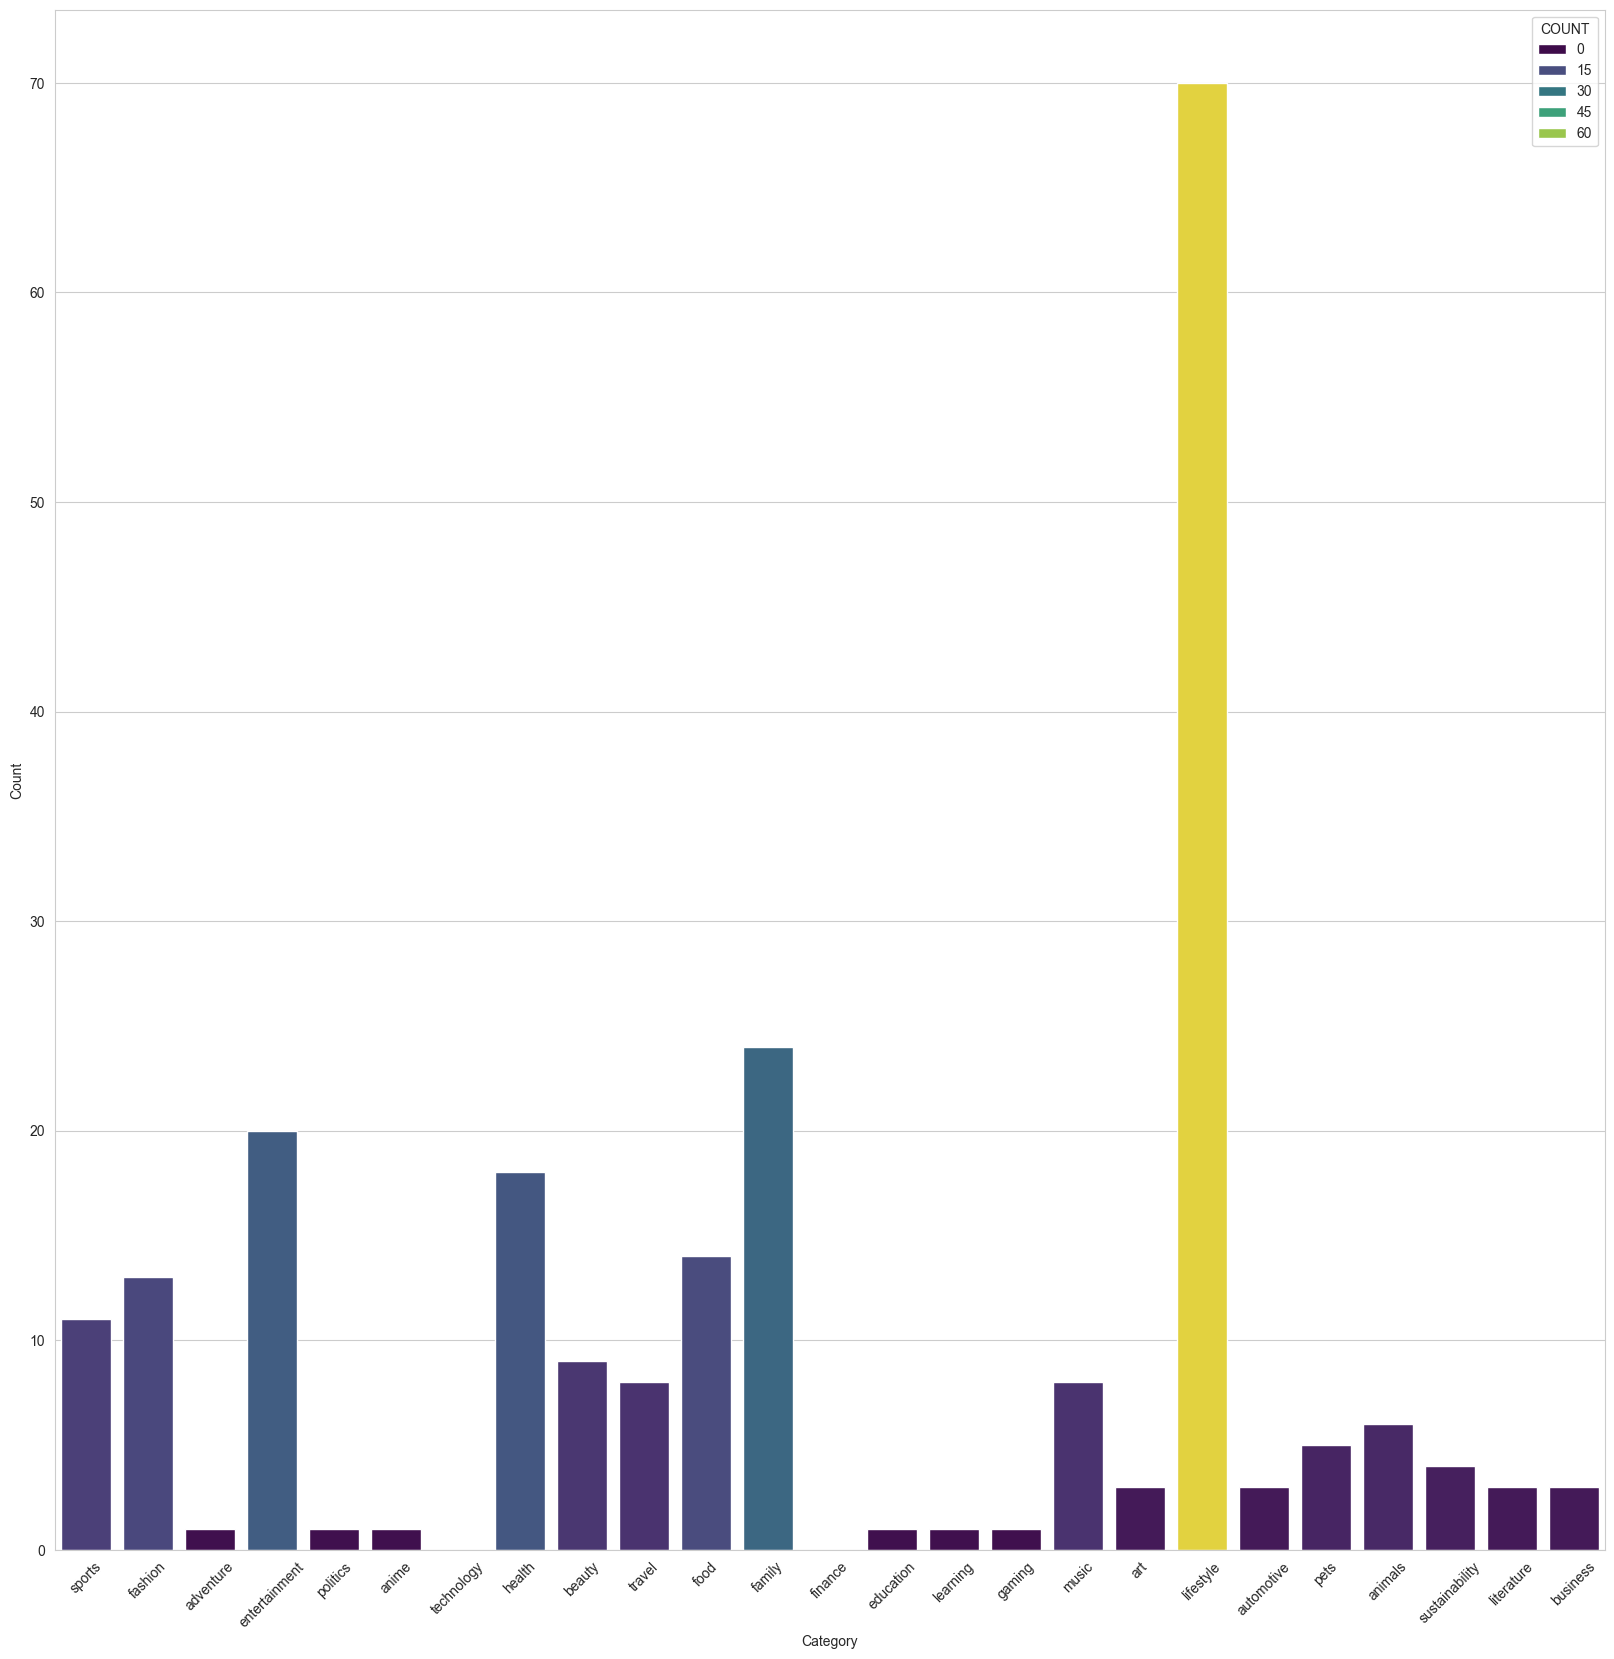

In [81]:
plt.figure(figsize=(20, 20))
sns.barplot(data=cat_df, x='CATEGORY', y='COUNT', palette='viridis', hue='COUNT')
plt.xticks(rotation = 45)
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

In [82]:
type_list = list(ad_based_influencer_dict.keys())
id_list = list(ad_based_influencer_dict.values())
count_list = [len(influencers) for influencers in id_list]
ad_df = pd.DataFrame({'CATEGORY': type_list, 'ID_LIST': id_list, 'COUNT': count_list})
ad_df

,CATEGORY,ID_LIST,COUNT
0,yes,"[588928, 67842, 81670, 553482, 194698, 123795,...",39
1,no,"[190468, 25989, 26245, 118034, 117525, 579606,...",30
2,maybe,"[114177, 1665, 578053, 105095, 142605, 114203,...",31


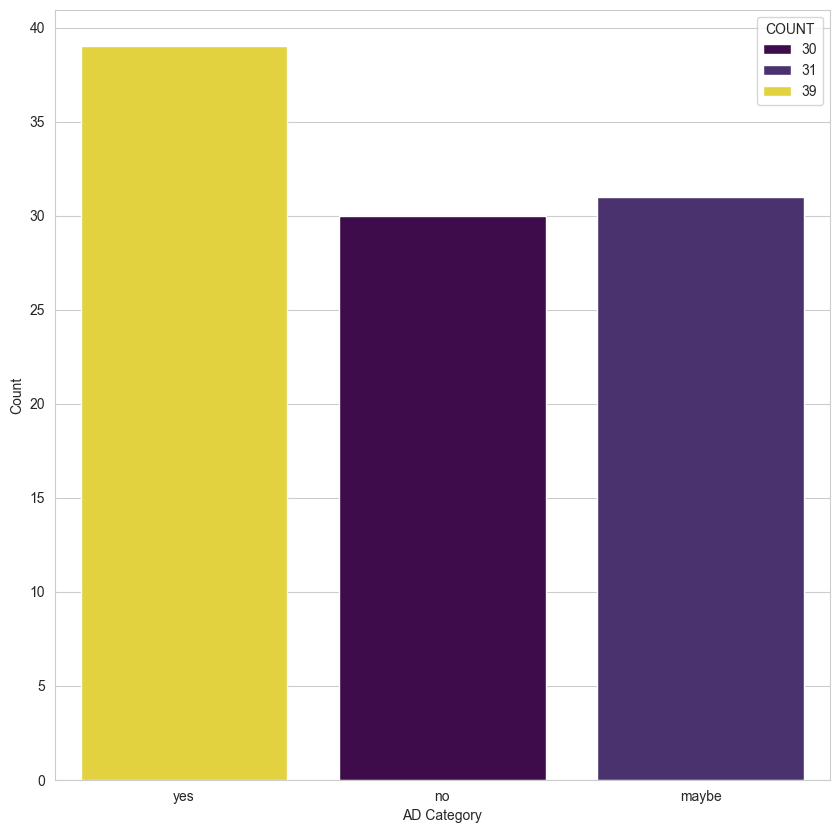

In [83]:
plt.figure(figsize=(10, 10))
sns.barplot(data=ad_df, x='CATEGORY', y='COUNT', palette='viridis', hue='COUNT')
plt.xlabel('AD Category')
plt.ylabel('Count')
plt.show()

In [91]:
type(cat_df.loc[cat_df['CATEGORY'] == 'lifestyle']['ID_LIST'].item())

list

In [97]:
n = int(input("Enter number of categories : "))
print(f"Number of categories : {n}")

query_cat_list = []
query_influencer_list = []

print("Categories : ")

for i in range(n):
    query_cat = input("Enter category : ")
    query_cat_list.append(query_cat)
    print(f"{query_cat}")

    if(i == 0):
        query_influencer_list = cat_df.loc[cat_df['CATEGORY'] == query_cat.lower()]['ID_LIST'].item()
    else:
        query_influencer_list = list(set(query_influencer_list).intersection(set(cat_df.loc[cat_df['CATEGORY'] == query_cat.lower()]['ID_LIST'].item())))

print(f"\nList of influencers :\n{query_influencer_list}")



Number of categories : 3
Categories : 
entertainment
lifestyle
family

List of influencers :
[102618, 97627, 67572]
